# Exploratory Data Analysis — CryptoDiversify

Looking at price trends, return distributions, and volatility for our 6 coins
(BTC, ETH, SOL, BNB, XRP, DOGE) before running the formal hypothesis tests in
`02_analysis.ipynb`.

In [1]:
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as scistats

conn = sqlite3.connect('../data/project.db')
prices = pd.read_sql('SELECT * FROM prices', conn)
returns = pd.read_sql('SELECT * FROM returns', conn)
conn.close()

prices['date'] = pd.to_datetime(prices['date'])
returns['date'] = pd.to_datetime(returns['date'])

prices_wide = prices.pivot(index='date', columns='coin', values='close_price')
returns_wide = returns.pivot(index='date', columns='coin', values='log_return')

CRASH_2022 = (pd.Timestamp('2022-05-01'), pd.Timestamp('2022-12-31'))
CRASH_2026 = (pd.Timestamp('2026-01-01'), pd.Timestamp('2026-06-30'))

prices_wide.head()

coin,BNB,BTC,DOGE,ETH,SOL,XRP
date,,,,,,
2021-01-01,37.7762,29331.69,0.005680,728.91,1.8421,0.23746
2021-01-02,38.2331,32178.33,0.010526,774.56,1.7999,0.22064
2021-01-03,41.2575,33000.05,0.009821,978.28,2.1779,0.22540
2021-01-04,41.1333,31988.71,0.009761,1041.43,2.4909,0.23565
2021-01-05,41.8219,33949.53,0.009970,1099.56,2.1636,0.22573


## Price trends (normalized to 100 at the start, log scale)

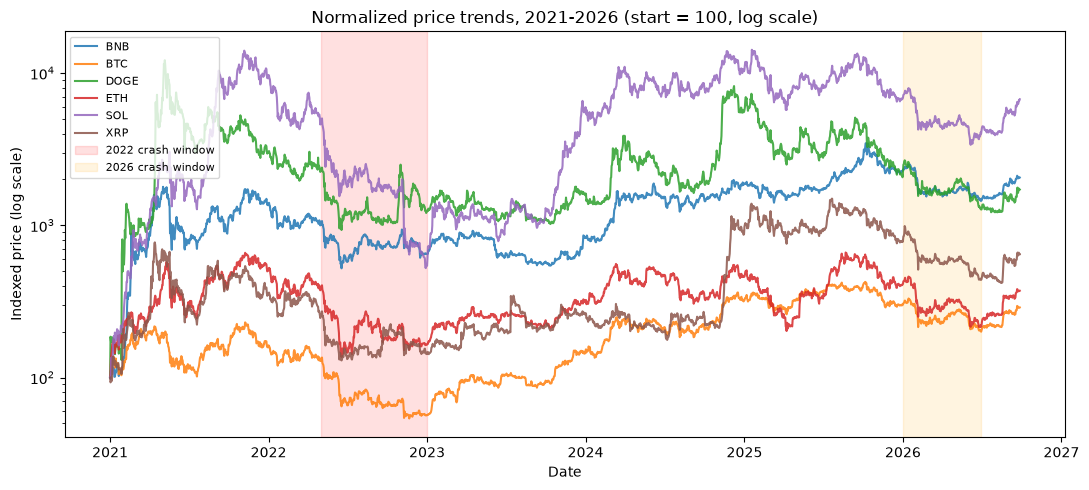

In [2]:
normalized = prices_wide / prices_wide.iloc[0] * 100

plt.figure(figsize=(11,5))
for coin in normalized.columns:
    plt.plot(normalized.index, normalized[coin], label=coin, alpha=0.85)
plt.axvspan(*CRASH_2022, color='red', alpha=0.12, label='2022 crash window')
plt.axvspan(*CRASH_2026, color='orange', alpha=0.12, label='2026 crash window')
plt.yscale('log')
plt.title('Normalized price trends, 2021-2026 (start = 100, log scale)')
plt.xlabel('Date'); plt.ylabel('Indexed price (log scale)')
plt.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

**Interpretation:** all six coins surged through 2021, fell sharply during the shaded
2022 window (Terra/Luna + FTX), recovered into the 2025 peak, then fell again during the
shaded 2026 window (war + Fed shock). The fact that every coin visibly drops inside *both*
shaded windows, at the same time, is an early visual hint supporting RQ1 — these assets
tend to move together especially during crises.

## Distribution of daily returns — do we see fat tails?

,mean,std,skew,excess_kurtosis
coin,,,,
BNB,0.001,0.041,0.832,25.102
BTC,0.001,0.030,-0.109,4.095
DOGE,0.001,0.070,6.470,138.484
ETH,0.001,0.040,-0.179,5.564
SOL,0.002,0.057,-0.363,9.187
XRP,0.001,0.050,1.267,17.796


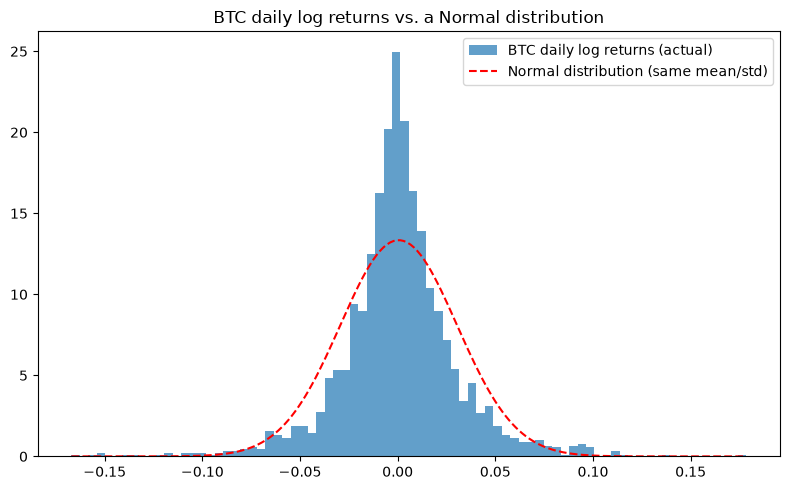

In [3]:
stats_table = pd.DataFrame({
    'mean': returns_wide.mean(),
    'std': returns_wide.std(),
    'skew': returns_wide.skew(),
    'excess_kurtosis': returns_wide.kurtosis(),
})
display(stats_table.round(3))

plt.figure(figsize=(8,5))
btc_r = returns_wide['BTC'].dropna()
plt.hist(btc_r, bins=80, density=True, alpha=0.7, label='BTC daily log returns (actual)')
x = np.linspace(btc_r.min(), btc_r.max(), 200)
plt.plot(x, scistats.norm.pdf(x, btc_r.mean(), btc_r.std()), 'r--',
         label='Normal distribution (same mean/std)')
plt.title('BTC daily log returns vs. a Normal distribution')
plt.legend()
plt.tight_layout()
plt.show()

**Interpretation:** excess kurtosis is well above 0 for every coin, meaning extreme
daily moves happen far more often than a Normal distribution would predict ("fat tails") —
a well-known feature of crypto returns. This matters for our later analysis: Markowitz
optimization only accounts for mean and variance, so it can understate real tail risk in
an asset class like this one — a limitation worth keeping in mind when interpreting the
Sharpe ratios in `02_analysis.ipynb`.

## Rolling 30-day annualized volatility over time

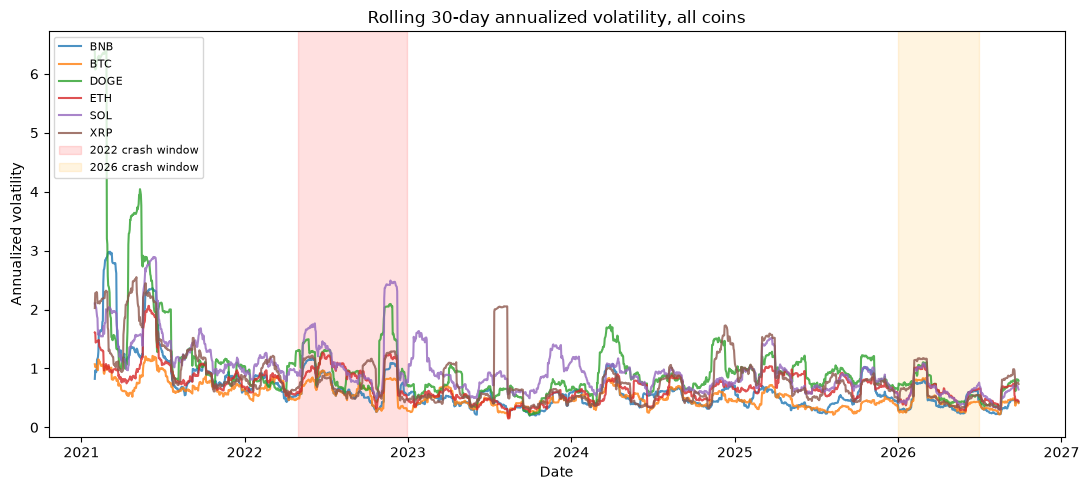

In [4]:
rolling_vol = returns_wide.rolling(30).std() * np.sqrt(365)

plt.figure(figsize=(11,5))
for coin in rolling_vol.columns:
    plt.plot(rolling_vol.index, rolling_vol[coin], label=coin, alpha=0.8)
plt.axvspan(*CRASH_2022, color='red', alpha=0.12, label='2022 crash window')
plt.axvspan(*CRASH_2026, color='orange', alpha=0.12, label='2026 crash window')
plt.title('Rolling 30-day annualized volatility, all coins')
plt.xlabel('Date'); plt.ylabel('Annualized volatility')
plt.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

**Interpretation:** volatility spikes visibly across *all* coins simultaneously inside
both shaded crash windows — consistent with "volatility clustering," a well-known property
of financial return series (calm periods stay calm, turbulent periods stay turbulent).

## Overall correlation heatmap (full 2021-2026 period)

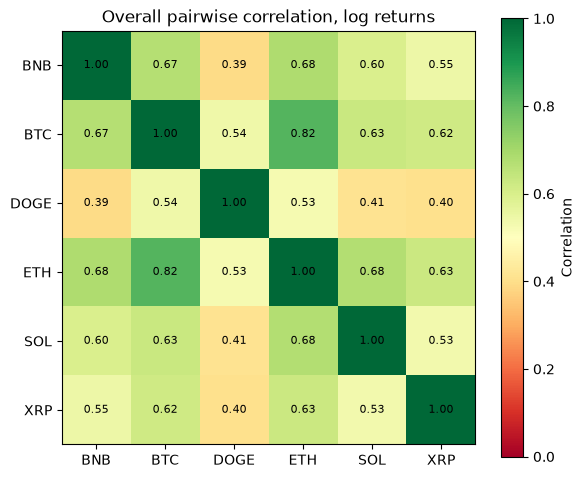

In [5]:
corr = returns_wide.corr()
fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(corr, cmap='RdYlGn', vmin=0, vmax=1)
ax.set_xticks(range(len(corr.columns))); ax.set_xticklabels(corr.columns)
ax.set_yticks(range(len(corr.columns))); ax.set_yticklabels(corr.columns)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f'{corr.values[i,j]:.2f}', ha='center', va='center', fontsize=8)
plt.colorbar(im, label='Correlation')
plt.title('Overall pairwise correlation, log returns')
plt.tight_layout()
plt.show()

**Interpretation:** BTC-ETH is the strongest pair (0.82); DOGE is consistently the
loosest fit with the rest (0.39-0.54). Nothing is negative — every pair moves somewhat
together even outside of crashes. The formal crash-vs-calm comparison is in
`02_analysis.ipynb`.